# Research question 3: how much does the audio path cost

Real contact-centre input is audio. Before the pipelines can extract anything, speech recognition must produce the transcript and, when both parties share one channel, diarisation must decide who spoke. Both steps make errors, and those errors flow into the extracted fields.

The aim is to quantify that damage with a paired design where the same 50 bank calls exist in four variants. `oracle` (human-corrected transcript, the reference), `asr` (the corpus machine transcript), `stereo` (audio with the speakers on known channels), and `mono` (audio where diarisation must infer the speakers). Every pipeline answers every variant, so each answer has its own oracle twin.

The numbers come from `evaluation/rq3/out/` (produced by `evaluation/run.py`).

In [1]:
# The repository root is the first parent directory holding docker-compose.yml
import csv
import json
from pathlib import Path

REPO = Path.cwd().resolve()
while not REPO.joinpath("docker-compose.yml").exists():
  REPO = REPO.parent

OUT = REPO.joinpath("evaluation", "rq3", "out")
print("reading from:", OUT)

reading from: /home/amed/uni/insight/evaluation/rq3/out


## The scores

Why this output: this table prices the audio path, every degraded variant is read against its oracle twin from the same calls.

- `accuracy` intent accuracy on the 26 calls whose task maps into the schema
- `wer` word error rate of the produced transcript against the oracle turns (substitutions + deletions + insertions over reference words, one pinned normalization). Empty for oracle, it is the reference
- `role` speaker-assignment accuracy, mono and stereo only: each produced line is matched to the oracle turn with the largest word overlap and judged against that turn's speaker
- `to_wrong` answers right on oracle but wrong on this variant (same call, same pipeline); `to_right` the reverse, errors the degradation accidentally fixed

In [2]:
scores_file = OUT.joinpath("scores.json")
if not scores_file.exists():
  print("no rq3 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(scores_file.read_text())
  print(f"{'variant':<8} {'pipeline':<9} {'accuracy':<9} {'wer':<7} {'role':<7} {'to_wrong':<9} {'to_right':<9} not_complete")
  for variant in ("oracle", "asr", "mono", "stereo"):
    for pipeline, s in scores.get(variant, {}).items():
      acc = f"{s['accuracy']:.2f}" if s["accuracy"] is not None else "-"
      wer = f"{s['mean_wer']:.3f}" if s["mean_wer"] is not None else "-"
      role = f"{s['mean_role_accuracy']:.3f}" if s["mean_role_accuracy"] is not None else "-"
      print(f"{variant:<8} {pipeline:<9} {acc:<9} {wer:<7} {role:<7} "
            f"{s['to_wrong']:<9} {s['to_right']:<9} {s['not_complete']}")

variant  pipeline  accuracy  wer     role    to_wrong  to_right  not_complete
oracle   p1        0.77      -       -       0         0         0
oracle   p2        0.23      -       -       0         0         0
oracle   p3        0.96      -       -       0         0         0
asr      p1        0.77      0.098   -       0         0         0
asr      p2        0.23      0.098   -       0         0         0
asr      p3        0.85      0.098   -       3         0         0
mono     p1        0.77      0.219   0.808   0         0         0
mono     p2        0.31      0.219   0.808   0         2         0
mono     p3        0.92      0.219   0.808   2         1         0
stereo   p1        0.77      0.386   0.964   0         0         0
stereo   p2        0.27      0.383   0.964   1         2         0
stereo   p3        0.92      0.390   0.965   2         1         0


## The picture

Why this output: the fall from the oracle bars to the audio bars is the cost this research question measures, and its size per pipeline is easier to judge as heights than as table rows.

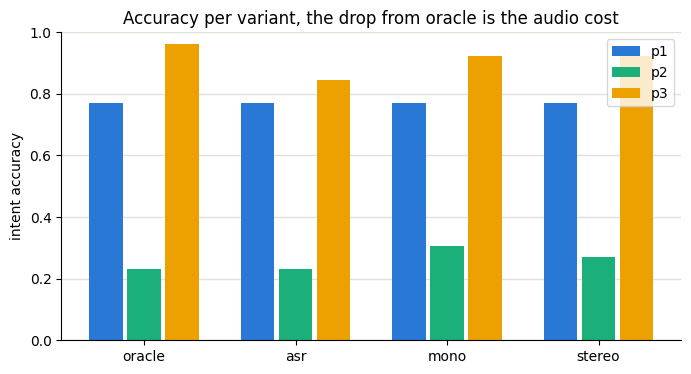

In [3]:
import matplotlib.pyplot as plt

COLORS = {"p1": "#2a78d6", "p2": "#1baf7a", "p3": "#eda100"}
VARIANTS = ("oracle", "asr", "mono", "stereo")

if not scores_file.exists():
  print("no rq3 scores yet; run evaluation/run.py first")
else:
  scores = json.loads(scores_file.read_text())

  fig, ax = plt.subplots(figsize=(8, 4))
  for offset, pipeline in enumerate(("p1", "p2", "p3")):
    xs = []
    ys = []
    for index, variant in enumerate(VARIANTS):
      s = scores.get(variant, {}).get(pipeline)
      if s is not None and s["accuracy"] is not None:
        xs.append(index + (offset - 1) * 0.25)
        ys.append(s["accuracy"])
    ax.bar(xs, ys, width=0.22, color=COLORS[pipeline], label=pipeline)

  ax.set_xticks(range(len(VARIANTS)))
  ax.set_xticklabels(VARIANTS)
  ax.set_ylim(0, 1)
  ax.set_ylabel("intent accuracy")
  ax.set_title("Accuracy per variant, the drop from oracle is the audio cost")
  ax.legend()
  ax.grid(axis="y", color="#e1e0d9", linewidth=1)
  ax.set_axisbelow(True)
  ax.spines["top"].set_visible(False)
  ax.spines["right"].set_visible(False)
  plt.show()

## The worst transcriptions

The calls where the produced transcript drifted furthest from the oracle. These are the records to read when explaining where audio errors come from.

In [4]:
results_file = OUT.joinpath("results.csv")
rows = list(csv.DictReader(open(results_file))) if results_file.exists() else []
with_wer = sorted((r for r in rows if r["wer"] != ""), key=lambda r: -float(r["wer"]))
if not with_wer:
  print("no rq3 results yet")
else:
  print(f"{'record':<26} {'variant':<8} {'pipeline':<9} {'wer':<7} {'gold':<20} predicted")
  for r in with_wer[:10]:
    print(f"{r['record']:<26} {r['variant']:<8} {r['pipeline']:<9} {r['wer']:<7} "
          f"{r['gold']:<20} {r['predicted']}")

record                     variant  pipeline  wer     gold                 predicted
hvb-035edd1d09c1433e       stereo   p3        0.7184  information_request  information_request
hvb-0002f70f7386445b       stereo   p1        0.675   replacement_request  information_request
hvb-0002f70f7386445b       stereo   p2        0.675   replacement_request  unknown
hvb-0002f70f7386445b       stereo   p3        0.675   replacement_request  replacement_request
hvb-07c661a60f194d1b       stereo   p1        0.6623  information_request  information_request
hvb-07c661a60f194d1b       stereo   p2        0.6623  information_request  unknown
hvb-07c661a60f194d1b       stereo   p3        0.6623  information_request  unknown
hvb-0a37e848a9c04e0c       stereo   p1        0.6237                       information_request
hvb-0a37e848a9c04e0c       stereo   p2        0.6237                       unknown
hvb-0a37e848a9c04e0c       stereo   p3        0.6237                       unknown


## What to conclude

Compare each variant's accuracy against oracle for the same pipeline: that gap is the cost of the audio path, and `to_wrong` names the calls that paid it. stereo isolates transcription error (roles are known by channel), mono adds diarisation on top, so mono minus stereo is the price of inferring speakers. Accent is not annotated in any public corpus and is a stated limitation. The machine-readable numbers live in `evaluation/rq3/out/scores.json` and `results.csv`.